## Comparing growth rate and phase speed between two experiments

### Import package

In [7]:
import h5py
import numpy as np

from typing import cast, Dict
from pathlib import Path

from matplotlib import pyplot as plt

In [8]:
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 14,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "legend.fontsize": 12,
        "figure.titlesize": 18,
    }
)

### Load growth rate and phase speed

In [9]:
input_dir: Path = Path("/work/b11209013/Kuang2008_v0.5.0/full")

# load NoRad growth rate
growthrate: Dict[str, np.ndarray] = {}
phasespeed: Dict[str, np.ndarray] = {}

with h5py.File(input_dir / "NoRad/EigenAnalysis.h5", "r") as norad_ds:

    k: np.ndarray = cast(h5py.Dataset, norad_ds["k"])[...] # angular wavenumber

    growthrate["norad"] = cast(h5py.Dataset, norad_ds["GrowthRates"])[..., 0]
    phasespeed["norad"] = cast(h5py.Dataset, norad_ds["PhaseSpeeds"])[..., 0]

with h5py.File(input_dir / "CldRad/EigenAnalysis.h5", "r") as cldrad_ds:

    growthrate["cldrad"] = cast(h5py.Dataset, cldrad_ds["GrowthRates"])[..., 0]
    phasespeed["cldrad"] = cast(h5py.Dataset, cldrad_ds["PhaseSpeeds"])[..., 0]

### Identify most unstable mode

In [10]:
most_unstable: np.intp = np.argmax(growthrate["norad"])


### Positive modal growth rates

Show only finite growth rates greater than zero for the selected mode (`GrowthRates[..., 0]`). Masked values leave gaps in each curve. Growth rates use the original data units.


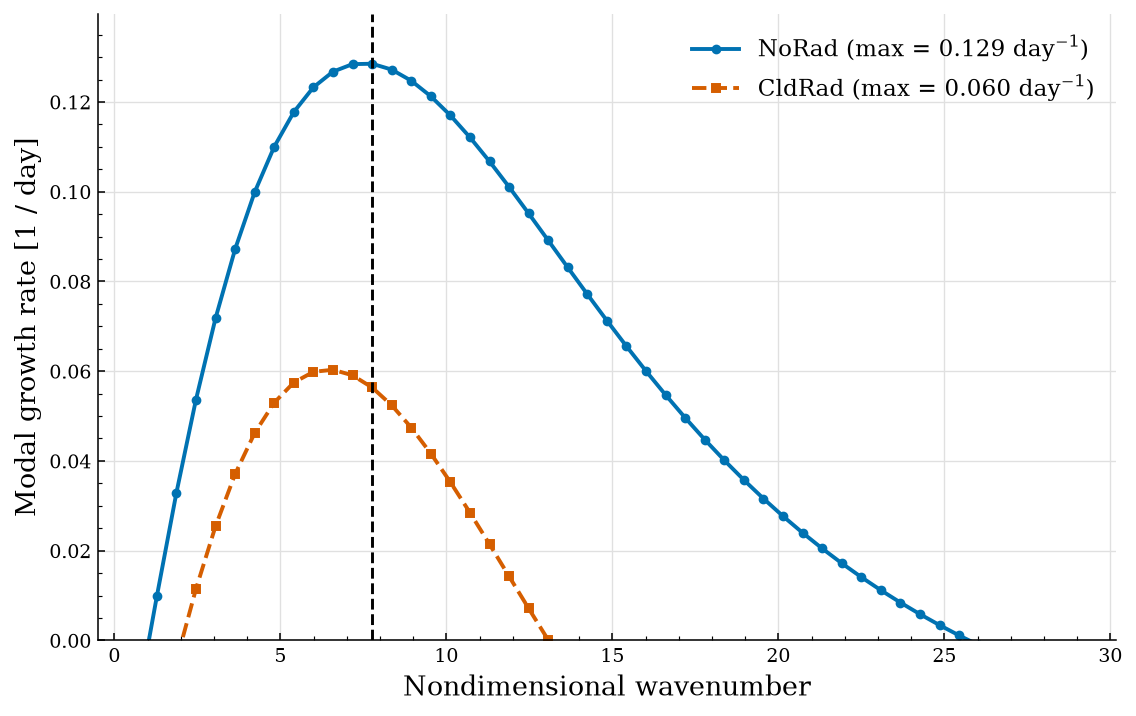

In [11]:
# Convert angular wavenumber using the existing nondimensionalization.
k_nondim: np.ndarray = 40000.0 * k / (2 * np.pi * 4320.0)

fig, ax = plt.subplots(figsize=(8, 5), dpi=140, layout="constrained")

styles = {
    "norad": {"label": "NoRad", "color": "#0072B2", "linestyle": "-", "marker": "o"},
    "cldrad": {"label": "CldRad", "color": "#D55E00", "linestyle": "--", "marker": "s"},
}
has_positive = False
for experiment, style in styles.items():
    rates = growthrate[experiment]
    valid = np.isfinite(k_nondim) & np.isfinite(rates)
    # Mask instead of removing points, so lines do not bridge nonpositive intervals.
    positive_rates = np.ma.masked_where(~valid, rates)
    has_positive = has_positive or bool(valid.any())
    finite_rates = rates[np.isfinite(rates)]
    max_text = f"{finite_rates.max():.3f} day$^{{-1}}$" if finite_rates.size else "N/A"
    legend_label = f"{style['label']} (max = {max_text})"
    ax.plot(k_nondim, positive_rates, linewidth=2, markersize=4,
            **{**style, "label": legend_label})
ax.axvline(k_nondim[most_unstable], color="k", linestyle="dashed")
ax.set(
    xlabel="Nondimensional wavenumber",
    ylabel="Modal growth rate [1 / day]",
)
ax.minorticks_on()
ax.tick_params(axis='both', which="both", direction='in') 
ax.set_ylim(bottom=0)
ax.margins(x=0.02)
ax.set_axisbelow(True)
ax.grid(True, color="0.88", linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=10)
ax.legend(frameon=False)

plt.savefig("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/experiment_contrast/growthrate_contrast.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


### Modal phase speeds

Compare the selected mode (`PhaseSpeeds[..., 0]`) using the same nondimensional wavenumber and experiment styles as above. Phase speeds are shown in the original data units; the input files do not specify units. Nonfinite values leave gaps in the curves. The dashed black line marks the wavenumber of the most unstable NoRad mode, as in the growth-rate figure.


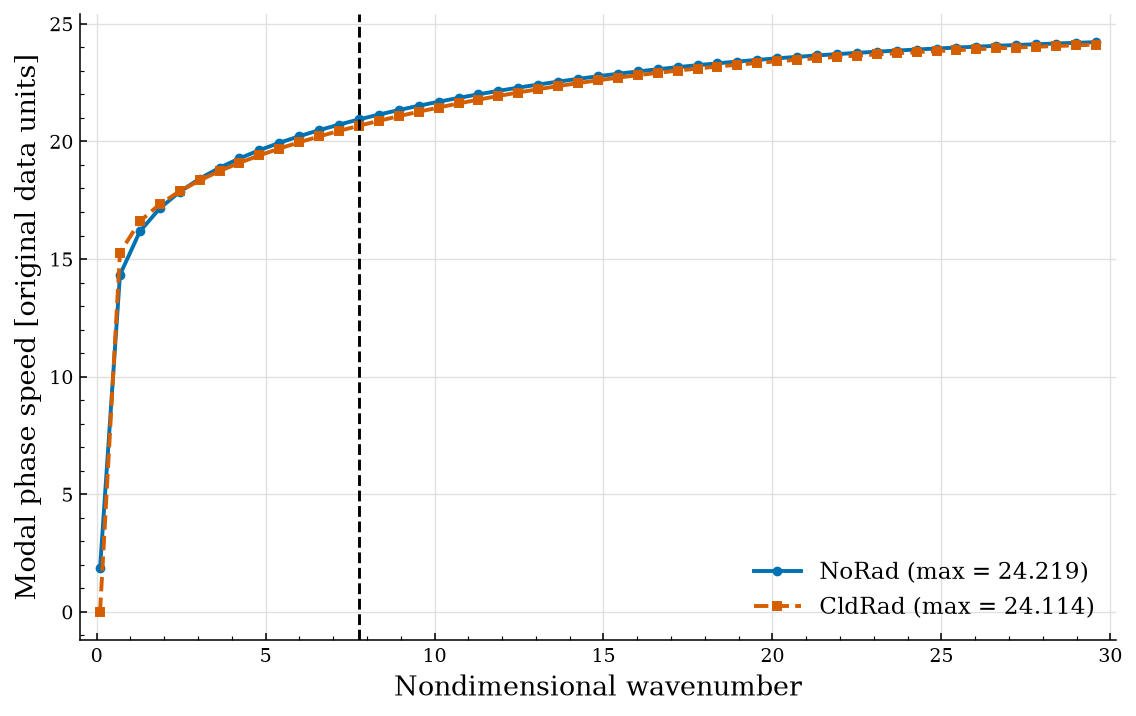

In [12]:
# Use the same wavenumber, experiment styles, and reference mode as above.
fig, ax = plt.subplots(figsize=(8, 5), dpi=140, layout="constrained")

for experiment, style in styles.items():
    speeds = phasespeed[experiment]
    valid = np.isfinite(k_nondim) & np.isfinite(speeds)
    masked_speeds = np.ma.masked_where(~valid, speeds)
    finite_speeds = speeds[valid]
    max_text = f"{finite_speeds.max():.3f}" if finite_speeds.size else "N/A"
    legend_label = f"{style['label']} (max = {max_text})"
    ax.plot(k_nondim, masked_speeds, linewidth=2, markersize=4,
            **{**style, "label": legend_label})

ax.axvline(k_nondim[most_unstable], color="k", linestyle="dashed")
ax.set(
    xlabel="Nondimensional wavenumber",
    ylabel="Modal phase speed [original data units]",
)
ax.minorticks_on()
ax.tick_params(axis="both", which="both", direction="in")
ax.margins(x=0.02)
ax.set_axisbelow(True)
ax.grid(True, color="0.88", linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=10)
ax.legend(frameon=False)

output_path = Path("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/experiment_contrast/phasespeed_contrast.png")
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)
